In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import h5py
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [112]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,        # 默认字体大小
    "axes.labelsize": 10,   # 轴标签字体大小
    "legend.fontsize": 10,  # 图例字体大小
    "mathtext.fontset": "stix",  # 数学字体设置为 STIX，这个与 Times New Roman 很接近
})

In [113]:
def colorbar(mappable):
  """ the way matplotlib colorbar should have been implemented """
  from mpl_toolkits.axes_grid1 import make_axes_locatable
  ax = mappable.axes
  fig = ax.figure
  divider = make_axes_locatable(ax)
  cax = divider.append_axes("right", size="5%", pad=0.05)
  return fig.colorbar(mappable, cax=cax)

In [114]:
ddpm_dir = "/root/Projects/ipole/output/riaf/job1/files_20241017_plot/epoch5000/epoch5000(3)/"
origin_dir = "/root/hdd256/ipole/files_20250102_2161/"

file_name = "-0.15812528_-0.23035592_-0.73242348_1.27275455_-0.89741212_1.00000000_1.45299816_1743036830.7716599.npz"
hdf5_file_name = "0ayg0903fy.h5"

# file_name = "-1.10572982_-0.21688251_1.40973938_-1.43954980_0.66454762_-1.00000000_1.36639559_1743036831.4706223.npz"
# hdf5_file_name = "2s2uec4ev4.h5"

# file_name = "-1.62377918_1.59239209_-0.10340550_-0.88202512_-0.56075144_1.00000000_-0.78904539_1743036831.5982394.npz"
# hdf5_file_name = "2z6uf1vtnr.h5"

# file_name = "-0.61794829_1.29704452_0.57314211_1.15867972_0.36384183_-1.00000000_-0.29829764_1743036831.7280293.npz"
# hdf5_file_name = "6fi18b00xj.h5"

# file_name = "-0.75132871_0.00178749_0.48213395_1.13676238_1.65804362_-1.00000000_-0.41376770_1743036831.8636024.npz"
# hdf5_file_name = "56wgri9jba.h5"

# file_name = "0.89000434_0.63008314_0.54388303_-1.63228858_-1.03756547_-1.00000000_0.26943013_1743036831.9986033.npz"
# hdf5_file_name = "bjgaihfn8e.h5"

# file_name = "-0.14753099_0.74655336_0.43457708_1.31304312_-1.72562110_-1.00000000_0.74093282_1743036832.1311398.npz"
# hdf5_file_name = "bwsgayu13v.h5"

# file_name = "-1.72317064_0.89570636_-0.93302161_-1.44034672_1.51675570_-1.00000000_0.71206534_1743036832.261141.npz"
# hdf5_file_name = "hgmbvhwu1u.h5"

# file_name = "0.63514787_-0.37458023_1.72435200_-1.35809720_1.58727932_-1.00000000_-0.22131760_1743036832.3936672.npz"
# hdf5_file_name = "itwj83lujf.h5"

ddpm_imput_file = ddpm_dir + file_name
origin_imput_file = origin_dir + hdf5_file_name


In [115]:
FOV_UNITS = "muas"
# 加载HDF5文件
hfp = h5py.File(origin_imput_file,'r')
# 从文件中读取所需元数据
dx = hfp['header']['camera']['dx'][()]
dsource = hfp['header']['dsource'][()]
lunit = hfp['header']['units']['L_unit'][()]
scale = hfp['header']['scale'][()]
freq = hfp['header']['freqcgs'][()]
# 计算视场大小（以微弧秒为单位）
fov_muas = dx / dsource * lunit * 2.06265e11
extent = [ -fov_muas/2, fov_muas/2, -fov_muas/2, fov_muas/2 ]
imagep = np.copy(hfp['unpol']).transpose((1,0))
I = imagep
hfp.close()
flux = I.sum()*scale
print(I.sum()*scale)
c_cgs = 2.99792458e10
k_cgs = 1.38064852e-16
Tb = c_cgs**2/(2*freq**2*k_cgs) * I

0.5007127566881028


In [116]:
ddpm_file_im = np.load(ddpm_imput_file)
ddpm_im = ddpm_file_im['image_array']

ddpm_scale = 0.5/ddpm_im.sum()

ddpm_im_cgs = ddpm_im*ddpm_scale

ddpm_im_Tb = c_cgs**2/(2*freq**2*k_cgs) * ddpm_im_cgs

In [117]:
# # 使用OpenCV找到圆环中心
# import cv2

# # 将图像转换为uint8类型,便于处理
# img = (ddpm_im * 255 / ddpm_im.max()).astype(np.uint8)

# # 使用高斯模糊减少噪声
# blur = cv2.GaussianBlur(img, (5,5), 0)

# # 使用Canny边缘检测
# edges = cv2.Canny(blur, 50, 150)

# # 找到轮廓
# contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # 找到最大轮廓
# max_contour = max(contours, key=cv2.contourArea)

# # 计算轮廓的中心点
# M = cv2.moments(max_contour)
# center_x = int(M['m10']/M['m00'])
# center_y = int(M['m01']/M['m00'])

# # 计算需要平移的距离
# shift_x = nx//2 - center_x
# shift_y = ny//2 - center_y

# # 构建平移矩阵
# M = np.float32([[1, 0, shift_x],
#                 [0, 1, shift_y]])

# # 对图像进行平移变换
# centered_im = cv2.warpAffine(ddpm_im, M, (nx, ny))

# centered_im

1.511245145252468


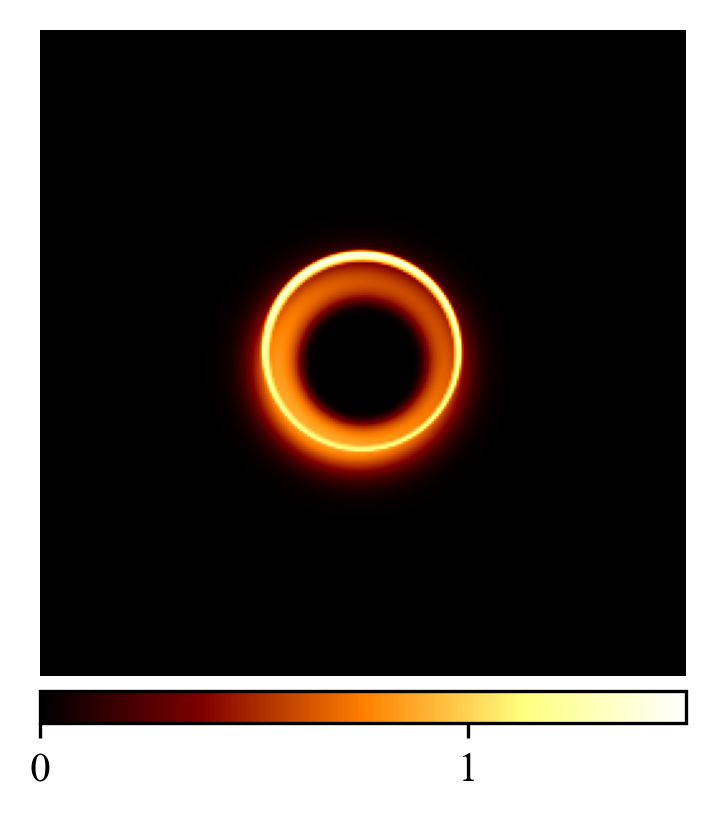

In [118]:
fig1, ax1 = plt.subplots(1,1,figsize=(3,3),dpi=300)
im = ax1.imshow(Tb, cmap='afmhot', vmin=0., vmax=Tb.max(), origin='lower')
ax1.axis('off')

# 创建水平colorbar
divider = make_axes_locatable(ax1)
cax = divider.append_axes("bottom", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

# 设置刻度,除以10e10并只保留整数位置
vmax = Tb.max()
print(vmax/1e10)
ticks = np.arange(0, int(vmax/1e10)+1,1)  # 生成11个点以便找到整数位置
if len(ticks) > 6:
    ticks = ticks[::2]
cbar.set_ticks(ticks*1e10)
cbar.set_ticklabels([f'{int(t)}' for t in ticks])

plt.show()
plt.close()

1.1321122816
[0 1]


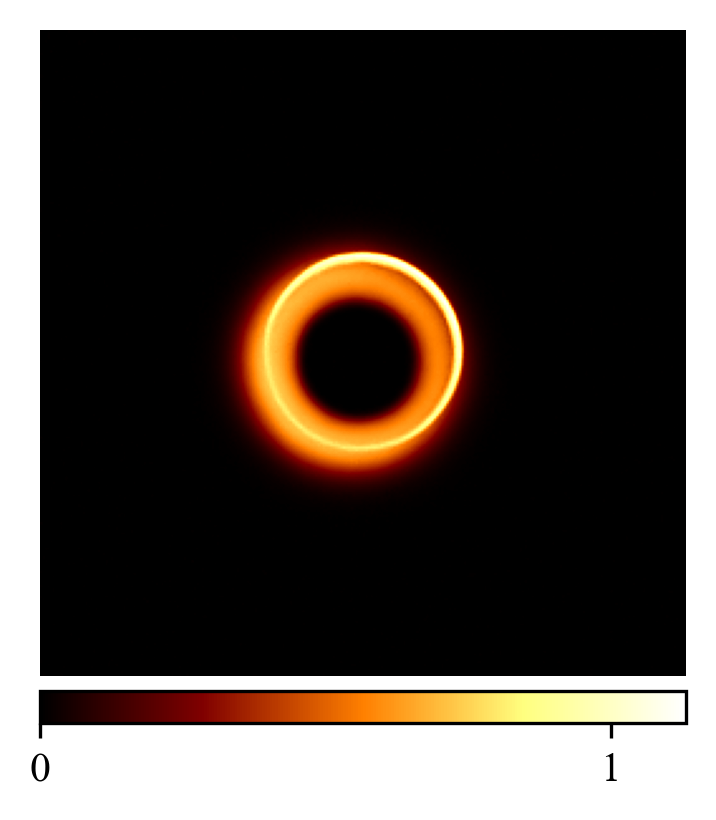

In [119]:
fig3, ax3 = plt.subplots(1,1,figsize=(3,3),dpi=300)
im = ax3.imshow(ddpm_im_Tb, cmap='afmhot', vmin=0., vmax=ddpm_im_Tb.max(), origin='upper')
ax3.axis('off')

# 创建水平colorbar
divider = make_axes_locatable(ax3)
cax = divider.append_axes("bottom", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

# 设置刻度,除以10e10并只保留整数位置
vmax = ddpm_im_Tb.max()
print(vmax/1e10)
ticks = np.arange(0, int(vmax/1e10)+1,1)
print(ticks)
if len(ticks) > 6:
    ticks = ticks[::2]
cbar.set_ticks(ticks*1e10)
cbar.set_ticklabels([f'{int(t)}' for t in ticks])

plt.show()
plt.close()